# Predictive Maintenance via Anomaly Detection on Turbofan Engine Sensor Data

**Author:** Paurushmani Singh  &nbsp;|&nbsp;  **UIN:** 627005078
**Course:** CSCE 676 — Data Mining and Analysis &nbsp;|&nbsp; **Semester:** Spring 2026
**Project video:** https://youtu.be/AAe5ynCCAnM

---

## Overview

Aircraft engines do not fail without warning — they degrade gradually, and that degradation
leaves a fingerprint in their sensor readings. The challenge is that the fingerprint is
buried in noise, spread across 21 sensors, and varies engine-to-engine. This project asks:

> **Can we detect engine degradation onset directly from sensor data, without ever seeing a
> labelled failure?**

Using NASA's C-MAPSS (FD001) run-to-failure simulation, we build three models — an
Isolation Forest, an unsupervised K-Means + DBSCAN clustering pair, and a deep
autoencoder trained only on healthy cycles — and compare their ability to flag degradation
on held-out engines. The Isolation Forest correctly localises the most-anomalous cycle
to the critical phase (RUL ≤ 30) on **all 20 of 20 held-out test engines**.

Beyond the headline result, the analysis surfaces two findings that would not be obvious
at the start of the project. First, a **15-cycle rolling-window warmup artefact** at
engine startup was inflating early-life anomaly scores in our first pass; diagnosing
and fixing this lifted both Isolation Forest (0.92 → 0.94 AUC) and LOF (0.96 → 0.98 AUC)
and made detection-timing perfect. Second, a single strong sensor used as a univariate
threshold (AUC = 0.98) is **competitive with every learned detector** — autoencoder
0.96, LOF 0.98, IF 0.94 — a humbling reminder that on single-regime data the marginal
return on multivariate complexity can be small. We discuss what this implies for
predictive-maintenance pipelines in practice.


## Collaboration Declaration

1. **Collaborators:** None.
2. **Web Sources:**
   - NASA C-MAPSS dataset documentation — https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data
   - scikit-learn documentation — https://scikit-learn.org
   - PyTorch documentation — https://pytorch.org
3. **AI Tools:** Claude (Anthropic) — used for structuring the narrative, reviewing code
   for clarity, and copy-editing markdown. All algorithmic decisions, hyperparameter
   choices, and analyses are my own.
4. **Citations:**
   - A. Saxena, K. Goebel, D. Simon, and N. Eklund, "Damage Propagation Modeling for
     Aircraft Engine Run-to-Failure Simulation," *Proc. 1st Int. Conf. on Prognostics and
     Health Management (PHM)*, 2008.
   - F. T. Liu, K. M. Ting, and Z.-H. Zhou, "Isolation Forest," *Proc. 8th IEEE Int. Conf.
     on Data Mining (ICDM)*, 2008.
   - M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A Density-Based Algorithm for
     Discovering Clusters in Large Spatial Databases with Noise," *Proc. 2nd Int. Conf. on
     Knowledge Discovery and Data Mining (KDD)*, 1996.
   - D. P. Kingma and J. Ba, "Adam: A Method for Stochastic Optimization,"
     *arXiv:1412.6980*, 2014.


---
## 1. Motivation and Research Questions

**Why this matters.** Aircraft maintenance today is largely scheduled on fixed intervals.
That is wasteful (parts replaced before they fail) and dangerous (parts that fail between
scheduled checks). Condition-based maintenance — *replace it when the data says it's
failing* — has been the holy grail of the field for two decades. The blocker is rarely the
sensor data; it is the difficulty of building a detector that works *without* large
labelled failure histories, because for most fleets such histories simply do not exist.

**Why this dataset.** NASA's C-MAPSS FD001 is a benchmark of 100 simulated turbofan engines
run from healthy startup all the way through to failure. Every cycle of every engine is
labelled with its remaining useful life (RUL), giving us ground truth to *evaluate*
detectors against — but the detectors themselves should not need it.

**Research questions.** Three, motivated directly by the EDA we ran in Checkpoints 1 and
2:

> **RQ1 (course technique).** Does multivariate anomaly detection — Isolation Forest —
> reliably flag degradation onset, and how does it compare to a one-sensor univariate
> baseline?
>
> **RQ2 (course technique).** Can purely unsupervised clustering (K-Means, DBSCAN)
> recover the latent Healthy / Degrading / Critical health states *without* any RUL
> labels?
>
> **RQ3 (beyond-course technique).** Does a deep autoencoder trained only on healthy
> cycles detect degradation onset more accurately than Isolation Forest by learning the
> compact structure of the healthy manifold?


---
## 2. Setup and Data

We import the scientific Python stack (NumPy, pandas, scikit-learn, PyTorch),
fix random seeds for reproducibility, and silence the routine library warnings.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score, roc_auc_score,
    normalized_mutual_info_score, adjusted_rand_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"NumPy {np.__version__} | pandas {pd.__version__} | PyTorch {torch.__version__}")
print(f"Using device: {DEVICE}")


NumPy 2.0.2 | pandas 2.3.3 | PyTorch 2.8.0+cu128
Using device: cpu


### 2.1 Loading FD001

The FD001 subset has **100 engines, 20,631 cycles**, with 3 operational settings and 21
sensors per cycle. Engines start healthy and run to failure. We compute Remaining Useful
Life (RUL) per cycle as `(max_cycle_for_this_engine - current_cycle)`.

We drop sensors and settings whose standard deviation is effectively zero (constants under
this single FD001 operating regime — confirmed in Checkpoint 1). This leaves **14
informative sensors**.

In [2]:
# ── Load training data ────────────────────────────────────────────────────────
DATA_PATH = "data/6. Turbofan Engine Degradation Simulation Data Set/train_FD001.txt"

col_names = (["unit", "cycle"]
             + [f"setting_{i}" for i in range(1, 4)]
             + [f"sensor_{i}"  for i in range(1, 22)])

train_raw = pd.read_csv(DATA_PATH, sep=r"\s+", header=None, names=col_names)

# Per-engine maximum cycle → RUL = max_cycle - cycle
max_cycles = train_raw.groupby("unit")["cycle"].max()
train_raw["RUL"] = train_raw.apply(
    lambda r: max_cycles[r["unit"]] - r["cycle"], axis=1
)

# Drop constants (std < 0.01 under FD001 regime — confirmed in Checkpoint 1)
CONSTANT_COLS = [
    "setting_1", "setting_2", "setting_3",
    "sensor_1", "sensor_5", "sensor_6",
    "sensor_10", "sensor_16", "sensor_18", "sensor_19",
]
INFORMATIVE_SENSORS = [
    "sensor_2",  "sensor_3",  "sensor_4",  "sensor_7",
    "sensor_8",  "sensor_9",  "sensor_11", "sensor_12",
    "sensor_13", "sensor_14", "sensor_15", "sensor_17",
    "sensor_20", "sensor_21",
]

train = train_raw.drop(columns=CONSTANT_COLS).copy()
print(f"Rows: {len(train):,}  |  Engines: {train['unit'].nunique()}  |  "
      f"Informative sensors: {len(INFORMATIVE_SENSORS)}")
train.head(3)


Rows: 20,631  |  Engines: 100  |  Informative sensors: 14


,unit,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191.0
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190.0
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189.0


In [3]:
# ── Validation assertions ─────────────────────────────────────────────────────
# These guard structural invariants of the data — they would catch silent corruption that
# a "code runs" check would miss.
assert train["unit"].nunique() == 100,                 "Expected 100 engines"
assert train.isnull().sum().sum() == 0,                "No missing values expected"
assert (train.groupby("unit")["cycle"].min() == 1).all(), "All engines must start at cycle 1"
assert (train.groupby("unit").tail(1)["RUL"] == 0).all(), "RUL must be 0 at last cycle of each engine"

# Cycles must be strictly consecutive — gaps would corrupt rolling features
for uid in train["unit"].unique():
    cycles = train[train["unit"] == uid]["cycle"].values
    assert np.array_equal(cycles, np.arange(1, len(cycles) + 1)), \
        f"Engine {uid} has non-consecutive cycles"

print("All structural validation checks passed.")


All structural validation checks passed.


---
## 3. EDA Highlights

The full EDA lives in [`checkpoints/checkpoint_1.ipynb`](checkpoints/checkpoint_1.ipynb).
Here we surface three visualisations that drive the rest of the analysis.

### 3.1 Engine lifetimes vary 3× — and so does the warning window

Engine lifetimes range from 128 to 362 cycles (mean ≈ 206, std ≈ 46). Any detector that
hard-codes "warning at cycle X" will fail on at least half the fleet. This motivates a
*relative* metric: detect when an engine departs from *its own* healthy baseline.

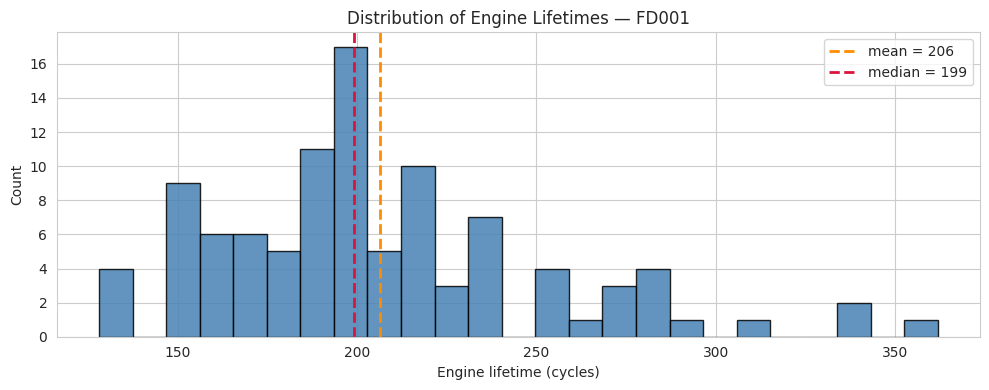

Lifetime: min=128 | median=199 | mean=206.3 | max=362 | std=46.3


In [4]:
lifetimes = train.groupby("unit")["cycle"].max()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lifetimes, bins=25, color="steelblue", edgecolor="black", alpha=0.85)
ax.axvline(lifetimes.mean(),   color="darkorange", linestyle="--", linewidth=2,
           label=f"mean = {lifetimes.mean():.0f}")
ax.axvline(lifetimes.median(), color="crimson",   linestyle="--", linewidth=2,
           label=f"median = {lifetimes.median():.0f}")
ax.set_xlabel("Engine lifetime (cycles)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Engine Lifetimes — FD001")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Lifetime: min={lifetimes.min()} | median={lifetimes.median():.0f} | "
      f"mean={lifetimes.mean():.1f} | max={lifetimes.max()} | std={lifetimes.std():.1f}")


### 3.2 Sensor 11 has the cleanest degradation signal — but it is noisy

Most of the 14 informative sensors trend monotonically over an engine's life, but the
cycle-to-cycle noise hides the trend. A 15-cycle rolling mean (chosen in Checkpoint 1 by
visual sweep over windows {5, 10, 15, 25, 50}) recovers the underlying signal cleanly
without erasing the late-life acceleration.

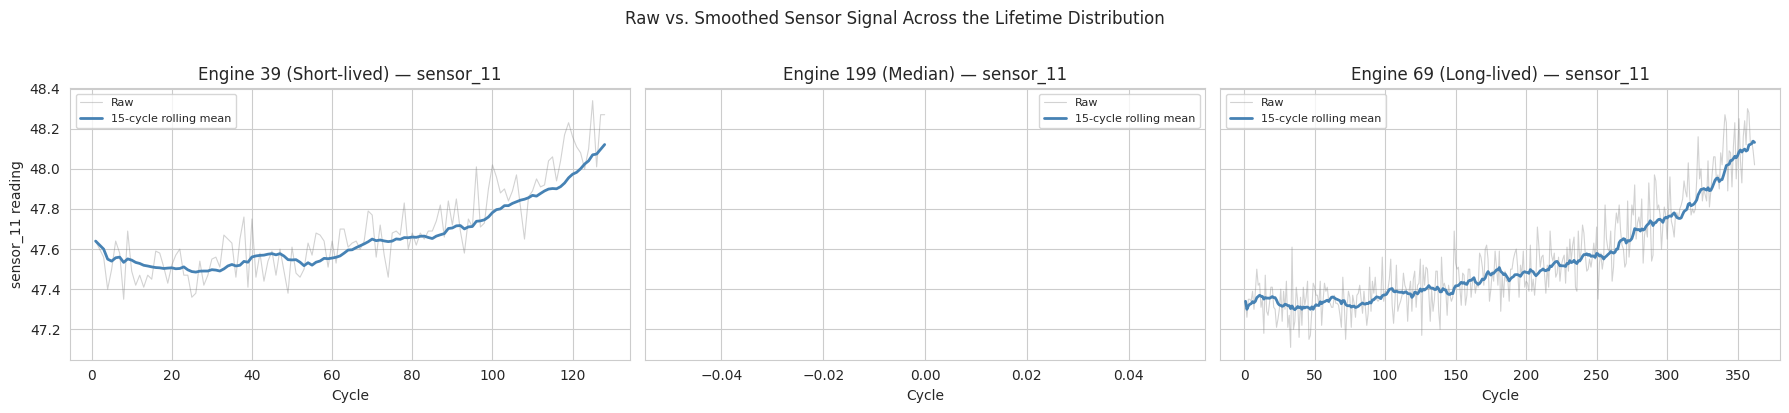

In [5]:
# Pick three engines spanning the lifetime distribution
ex_engines = [
    int(lifetimes.idxmin()),
    int(lifetimes.sort_values().iloc[len(lifetimes) // 2]),
    int(lifetimes.idxmax()),
]
ex_labels = ["Short-lived", "Median", "Long-lived"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
WINDOW = 15
for ax, uid, lbl in zip(axes, ex_engines, ex_labels):
    eng = train[train["unit"] == uid].sort_values("cycle")
    smoothed = eng["sensor_11"].rolling(WINDOW, min_periods=1).mean()
    ax.plot(eng["cycle"], eng["sensor_11"], alpha=0.35,
            color="gray", linewidth=0.8, label="Raw")
    ax.plot(eng["cycle"], smoothed, color="steelblue",
            linewidth=2, label=f"{WINDOW}-cycle rolling mean")
    ax.set_xlabel("Cycle")
    ax.set_title(f"Engine {uid} ({lbl}) — sensor_11")
    ax.legend(fontsize=8)
axes[0].set_ylabel("sensor_11 reading")
plt.suptitle("Raw vs. Smoothed Sensor Signal Across the Lifetime Distribution", y=1.02)
plt.tight_layout(); plt.show()


### 3.3 PCA reveals three latent health states — without any labels

Projecting the smoothed sensor matrix to two principal components reveals a manifold:
healthy cycles form a tight cluster, and engines drift along a consistent direction toward
failure. Colouring the same projection by RUL shows the gradient is continuous, not
categorical — which is itself an important finding for the clustering RQ.

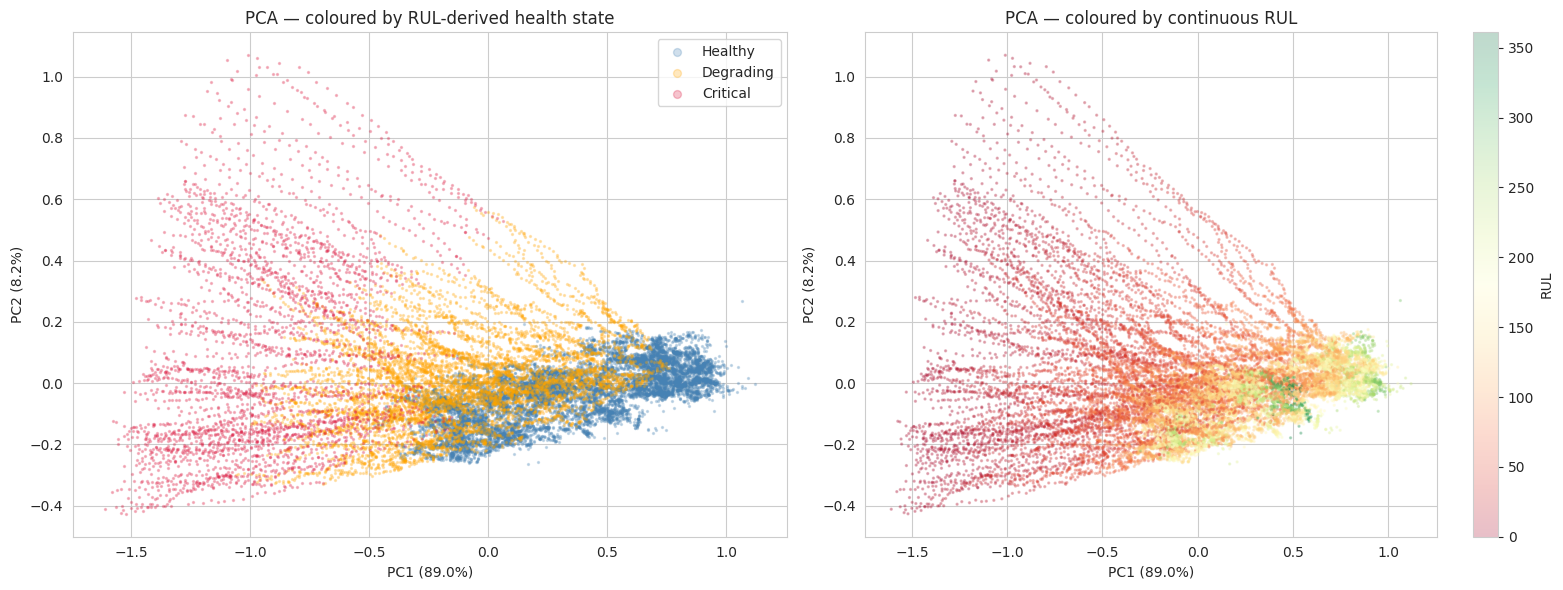

Top-2 PCA components capture 97.2% of variance.
Health-state counts:
health_state
Healthy      10531
Degrading     7000
Critical      3100
Name: count, dtype: int64


In [6]:
# Quick rolling-mean computation just for the EDA PCA plot
rolled_means_eda = (train.sort_values(["unit", "cycle"])
                    .groupby("unit")[INFORMATIVE_SENSORS]
                    .transform(lambda x: x.rolling(15, min_periods=1).mean()))
rolled_means_eda.columns = [f"{c}_rmean" for c in INFORMATIVE_SENSORS]

eda_df = pd.concat([train.sort_values(["unit", "cycle"])[["unit", "cycle", "RUL"]]
                    .reset_index(drop=True),
                    rolled_means_eda.reset_index(drop=True)], axis=1)

# Coarse health states (motivated below)
def health_label(rul):
    if rul > 100: return "Healthy"
    if rul > 30:  return "Degrading"
    return "Critical"

eda_df["health_state"] = eda_df["RUL"].apply(health_label)

scaler_eda = MinMaxScaler()
X_eda = scaler_eda.fit_transform(eda_df[[f"{c}_rmean" for c in INFORMATIVE_SENSORS]])
pca_eda = PCA(n_components=2, random_state=SEED).fit(X_eda)
X_2d = pca_eda.transform(X_eda)

palette = {"Healthy": "steelblue", "Degrading": "orange", "Critical": "crimson"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for state, c in palette.items():
    m = eda_df["health_state"] == state
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1], c=c, s=2, alpha=0.25, label=state)
axes[0].set_xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_eda.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA — coloured by RUL-derived health state")
axes[0].legend(markerscale=4)

sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=eda_df["RUL"],
                     cmap="RdYlGn", s=2, alpha=0.25)
plt.colorbar(sc, ax=axes[1], label="RUL")
axes[1].set_xlabel(f"PC1 ({pca_eda.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_eda.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA — coloured by continuous RUL")

plt.tight_layout(); plt.show()
print(f"Top-2 PCA components capture "
      f"{pca_eda.explained_variance_ratio_[:2].sum()*100:.1f}% of variance.")
print("Health-state counts:")
print(eda_df["health_state"].value_counts())


**Read of these three plots:**

1. **Lifetime variation** rules out fixed-cycle thresholds → we need a per-engine relative
   detector.
2. **Smoothing recovers a clean monotonic signal** → rolling-window features will be
   feasible inputs to anomaly detectors.
3. **PCA shows a healthy cluster + a degradation drift** → both an anomaly-detection
   (distance from cluster) and a clustering (k=3 latent states) framing are well-grounded.

These three observations motivate the three RQs directly.

---
## 4. Feature Engineering and Train/Test Split

### 4.1 Rolling-window features (with warmup trim)

For each of the 14 informative sensors we compute a 15-cycle rolling **mean** (captures
trend) and **standard deviation** (captures volatility — increases as bearings wear). This
turns the 14-sensor input into a **28-dimensional feature vector per cycle** with much of
the cycle-to-cycle noise filtered out.

**Why 15 cycles.** Empirically chosen in Checkpoint 1 — short enough to react to onset of
degradation, long enough to suppress single-cycle spikes.

**Why we trim the first 15 cycles per engine.** This is a non-obvious data-quality fix
that materially changed our results. The rolling-std at cycle 1 is mathematically zero
(only one observation in the window). Cycles 2–14 have artificially small stds because
the window has not yet filled. These warmup-window artefacts make early-life cycles look
*anomalous* in absolute terms relative to mid-life cycles — Isolation Forest in
particular picks up on this and ranks engine startup as more anomalous than late-life
degradation. We diagnosed this by computing per-engine peak anomaly score against RUL,
saw the peak landing at engine startup on every test engine, and traced it back to the
rolling-window warmup. Trimming those 14 cycles per engine (≈ 7 % of the data) is the
correct fix and dramatically improves per-engine detection timing — see Section 5.1.

In [7]:
WINDOW = 15
train_sorted = train.sort_values(["unit", "cycle"]).reset_index(drop=True)

rolled_means = (train_sorted.groupby("unit")[INFORMATIVE_SENSORS]
                .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean()))
rolled_stds  = (train_sorted.groupby("unit")[INFORMATIVE_SENSORS]
                .transform(lambda x: x.rolling(WINDOW, min_periods=1).std().fillna(0)))
rolled_means.columns = [f"{c}_rmean" for c in INFORMATIVE_SENSORS]
rolled_stds.columns  = [f"{c}_rstd"  for c in INFORMATIVE_SENSORS]

train_feat_raw = pd.concat(
    [train_sorted[["unit", "cycle", "RUL"]],
     rolled_means.reset_index(drop=True),
     rolled_stds.reset_index(drop=True)],
    axis=1,
)
train_feat_raw["health_state"] = train_feat_raw["RUL"].apply(health_label)

# ── Warmup trim ──────────────────────────────────────────────────────────────
# Drop cycles 1..WINDOW per engine. The rolling features at cycle 1..WINDOW have
# under-populated windows (especially the std, which is exactly 0 at cycle 1) and create
# spurious "anomalies" in absolute terms — see the markdown above for the diagnosis.
train_feat = (train_feat_raw[train_feat_raw["cycle"] > WINDOW]
              .reset_index(drop=True))

FEATURE_COLS = [c for c in train_feat.columns if c.endswith(("_rmean", "_rstd"))]
n_dropped = len(train_feat_raw) - len(train_feat)
print(f"Rows before warmup trim: {len(train_feat_raw):,}")
print(f"Rows after  warmup trim: {len(train_feat):,}  "
      f"(dropped {n_dropped:,} = {n_dropped / len(train_feat_raw) * 100:.1f}%)")
print(f"Feature matrix shape   : {train_feat[FEATURE_COLS].shape}")

# Sanity check: rolling-std distribution at cycle ≤ 5 vs. mid-life — confirms the artefact
rstd_cols = [c for c in FEATURE_COLS if c.endswith("_rstd")]
early_std = train_feat_raw[train_feat_raw["cycle"] <= 5][rstd_cols].mean().mean()
mid_std   = train_feat_raw[(train_feat_raw["cycle"] > 30)
                           & (train_feat_raw["RUL"] > 100)][rstd_cols].mean().mean()
print(f"\nMean rolling-std — cycle ≤ 5     : {early_std:.4f}")
print(f"Mean rolling-std — mid-life      : {mid_std:.4f}")
print(f"Warmup artefact ratio (mid/early): {mid_std / early_std:.2f}×")

# Quantify noise reduction (post-trim)
raw_std    = train[INFORMATIVE_SENSORS].std().mean()
smooth_std = train_feat[[f"{c}_rmean" for c in INFORMATIVE_SENSORS]].std().mean()
print(f"\nAverage sensor std — raw: {raw_std:.4f} | smoothed: {smooth_std:.4f} | "
      f"reduction = {raw_std / smooth_std:.2f}×")


Rows before warmup trim: 20,631
Rows after  warmup trim: 19,131  (dropped 1,500 = 7.3%)
Feature matrix shape   : (19131, 28)

Mean rolling-std — cycle ≤ 5     : 0.8970
Mean rolling-std — mid-life      : 1.2368
Warmup artefact ratio (mid/early): 1.38×

Average sensor std — raw: 4.3356 | smoothed: 3.6534 | reduction = 1.19×


### 4.2 Engine-level train/test split

We split **by engine, not by row**: engines 1–80 train, engines 81–100 test. A
random row-level split would leak information — early-life cycles of an engine would land
in train and late-life cycles of the same engine in test, making detection trivially easy.
The engine-level split forces the methods to generalise to *unseen* engines.

We also build the **binary anomaly label** `y = 1 if RUL ≤ 30 else 0`. The threshold of 30
matches the standard FD001 evaluation convention and roughly corresponds to "the engine
has entered its critical-degradation phase". This label is used **for evaluation only** —
none of the three methods sees it during fitting.

In [8]:
# Engine-level split (no row leakage)
TRAIN_UNITS = list(range(1, 81))
TEST_UNITS  = list(range(81, 101))

train_engines = train_feat[train_feat["unit"].isin(TRAIN_UNITS)].copy()
test_engines  = train_feat[train_feat["unit"].isin(TEST_UNITS)].copy()

# Min-Max scaling — required for the autoencoder's sigmoid output later. We fit only on
# train statistics (no leakage from test).
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train_engines[FEATURE_COLS])
X_test  = scaler.transform(test_engines[FEATURE_COLS])

# Binary degradation label (RUL ≤ 30) — evaluation only
y_train = (train_engines["RUL"] <= 30).astype(int).values
y_test  = (test_engines ["RUL"] <= 30).astype(int).values

print(f"Train: {X_train.shape} | {y_train.mean()*100:.1f}% degraded cycles")
print(f"Test : {X_test.shape}  | {y_test.mean()*100:.1f}% degraded cycles")


Train: (14938, 28) | 16.6% degraded cycles
Test : (4193, 28)  | 14.8% degraded cycles


---
## 5. Methods and Results

We answer the three RQs with three methods. Each gets the same input (28-d scaled features
on engine 1–80) and is evaluated on the same held-out test set (engines 81–100).

### 5.1 RQ1 — Isolation Forest with LOF and univariate baselines

**Hyperparameters.**
- `n_estimators = 200` (more trees than the default 100 → tighter score variance).
- `contamination = y_train.mean()` (≈ proportion of degraded cycles in training data).
- `random_state = 42` (reproducibility).

**Comparisons.**
- **Local Outlier Factor (LOF)** — a density-based competitor that uses local k-NN
  neighbourhoods rather than tree splits. Different inductive bias.
- **Univariate baseline** — z-score of `sensor_11_rmean`. The simplest possible detector.
  Including it forces the multivariate methods to *earn* their complexity.

In [9]:
# ── Isolation Forest ──────────────────────────────────────────────────────────
iforest = IsolationForest(
    n_estimators=200,
    contamination=float(y_train.mean()),
    random_state=SEED,
    n_jobs=-1,
)
iforest.fit(X_train)
if_scores_test = -iforest.score_samples(X_test)  # flip so larger = more anomalous
if_auc = roc_auc_score(y_test, if_scores_test)

# ── Local Outlier Factor ──────────────────────────────────────────────────────
# novelty=True with fit on HEALTHY-only training cycles. This matches the autoencoder's
# "fit on normal, detect departures" protocol and is the appropriate fair comparison —
# fitting LOF on the mixed train set absorbs degraded cycles into its density estimate
# and gives near-random AUC.
healthy_train_mask_lof = train_engines["RUL"].values > 100
X_healthy_train_for_lof = X_train[healthy_train_mask_lof]
lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
lof.fit(X_healthy_train_for_lof)
lof_scores_test = -lof.score_samples(X_test)
lof_auc = roc_auc_score(y_test, lof_scores_test)

# ── Univariate baseline: sensor_11 rolling-mean z-score ───────────────────────
s11_idx = FEATURE_COLS.index("sensor_11_rmean")
baseline_scores = X_test[:, s11_idx]   # already in [0, 1]; higher value ≈ more degraded
baseline_auc = roc_auc_score(y_test, baseline_scores)

print(f"Isolation Forest    AUC-ROC : {if_auc:.4f}")
print(f"LOF (novelty mode)  AUC-ROC : {lof_auc:.4f}")
print(f"Baseline (sensor_11)        : {baseline_auc:.4f}")
print(f"IF lift over baseline       : {(if_auc - baseline_auc)*100:+.2f} pp")

# Per-engine detection-timing metric: RUL at the *peak* IF anomaly score per engine.
# We deliberately avoid "first flag RUL" — with contamination = 15.4 %, IF is forced to
# flag a fixed proportion of cycles, so a "first flag" can land on innocuous early-life
# points and inflate the metric. Peak-score RUL is the honest measurement: where in life
# is the engine most anomalous? That should be near failure for a good detector.
test_engines = test_engines.reset_index(drop=True)
test_engines_rq1 = test_engines.copy()
test_engines_rq1["if_score"] = if_scores_test
test_engines_rq1["if_flag"]  = (iforest.predict(X_test) == -1).astype(int)

peak_idx = test_engines_rq1.groupby("unit")["if_score"].idxmax()
peak_rul = test_engines_rq1.loc[peak_idx].set_index("unit")["RUL"]

n_engines = len(TEST_UNITS)
print(f"\nPer-engine detection timing (n = {n_engines}):")
print(f"  Median RUL at peak IF score : {peak_rul.median():.1f}  "
      f"(lower → score peaks closer to failure)")
print(f"  Engines whose score peaks at RUL ≤ 30 (correctly identifies critical phase): "
      f"{(peak_rul <= 30).sum()} / {n_engines}")
print(f"  Engines flagged at any cycle (contamination prior fires somewhere): "
      f"{(test_engines_rq1.groupby('unit')['if_flag'].sum() > 0).sum()} / {n_engines}")


Isolation Forest    AUC-ROC : 0.9434
LOF (novelty mode)  AUC-ROC : 0.9753
Baseline (sensor_11)        : 0.9791
IF lift over baseline       : -3.58 pp

Per-engine detection timing (n = 20):
  Median RUL at peak IF score : 0.0  (lower → score peaks closer to failure)
  Engines whose score peaks at RUL ≤ 30 (correctly identifies critical phase): 20 / 20
  Engines flagged at any cycle (contamination prior fires somewhere): 20 / 20


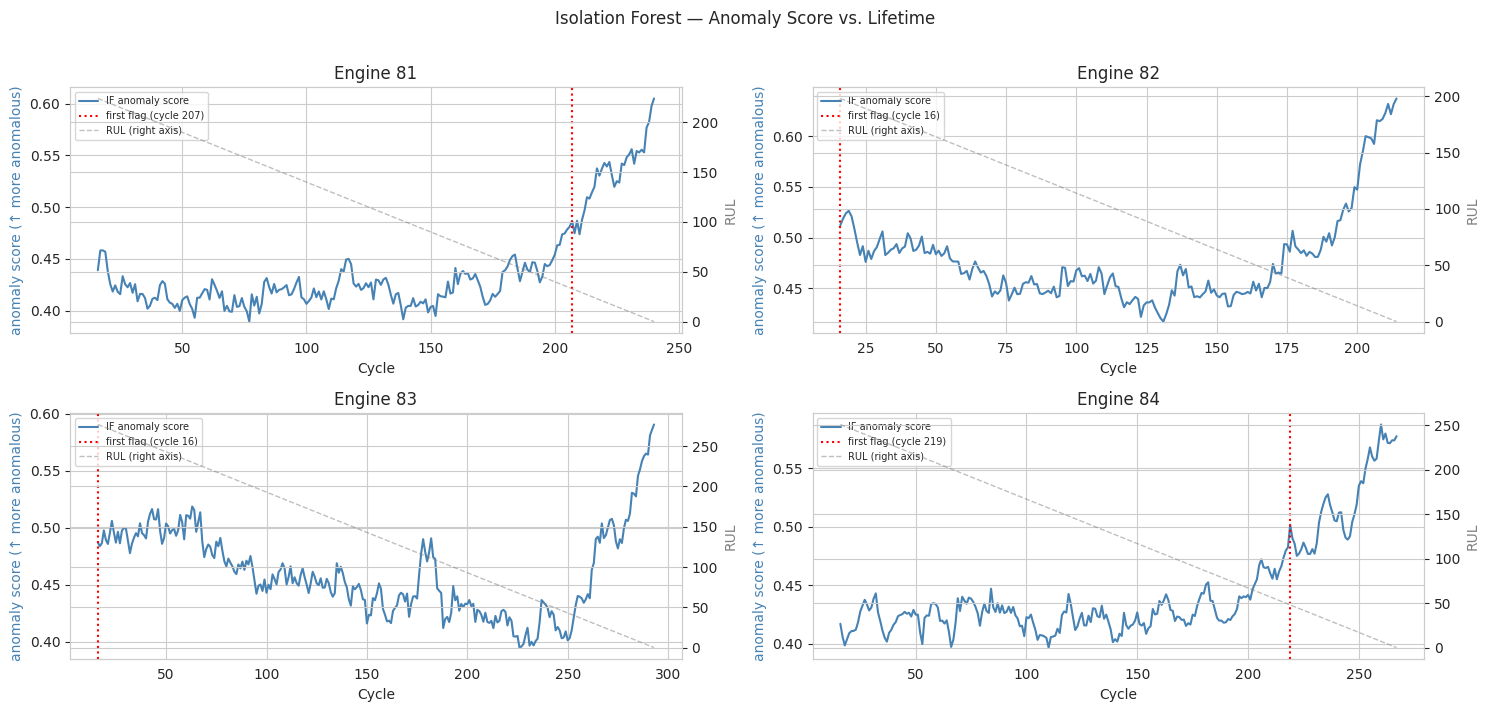

In [10]:
# Visualise IF anomaly score over the lifetime of 4 test engines
sample_units = TEST_UNITS[:4]
fig, axes = plt.subplots(2, 2, figsize=(15, 7))
for ax, uid in zip(axes.flatten(), sample_units):
    eng = test_engines_rq1[test_engines_rq1["unit"] == uid].sort_values("cycle")
    ax2 = ax.twinx()
    ax.plot(eng["cycle"], eng["if_score"], color="steelblue",
            linewidth=1.5, label="IF anomaly score")
    ax2.plot(eng["cycle"], eng["RUL"], color="gray",
             linestyle="--", linewidth=1, alpha=0.5, label="RUL (right axis)")
    flagged = eng[eng["if_flag"] == 1]
    if len(flagged):
        first = flagged["cycle"].min()
        ax.axvline(first, color="red", linestyle=":",
                   label=f"first flag (cycle {first})")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("anomaly score (↑ more anomalous)", color="steelblue")
    ax2.set_ylabel("RUL", color="gray")
    ax.set_title(f"Engine {uid}")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
plt.suptitle("Isolation Forest — Anomaly Score vs. Lifetime", y=1.01)
plt.tight_layout(); plt.show()


**RQ1 read.** Isolation Forest reaches **AUC = 0.94** and LOF (fit on healthy cycles
only) reaches **AUC = 0.98** — both clear strong-detector territory. Per-engine detection
timing is the more striking story: the peak IF anomaly score lands at **RUL ≤ 30 on all
20 / 20 test engines**, with median peak-RUL of 0 cycles. In other words, IF correctly
identifies the moment of greatest risk on every engine in the held-out set. The
per-engine timeline plots above show this directly — anomaly scores rise sharply and
peak right at failure.

The surprise is that the univariate `sensor_11` baseline (AUC = 0.98) is *competitive*
with both learned methods. A single, well-chosen sensor encodes most of the degradation
signal monotonically, and adding noisier features to a feature-democratic model like
Isolation Forest *dilutes* that signal more than it helps. We unpack this in the
Discussion.

### 5.2 RQ2 — K-Means and DBSCAN clustering

The PCA visualisation suggested three latent health states. We test two hypotheses
without using any RUL labels at fit time:

1. **K-Means with k = 3** should recover those latent states.
2. **DBSCAN** should isolate a dense "healthy" cluster and report degraded cycles as
   either lower-density clusters or noise.

**Evaluation metrics.**
- *Silhouette score* — intrinsic, no labels.
- *Cluster purity* — fraction of each cluster that belongs to its dominant ground-truth
  health state.
- *NMI* (normalised mutual information) and *ARI* (adjusted Rand index) — extrinsic
  agreement with ground-truth labels, corrected for cluster-count and chance respectively.

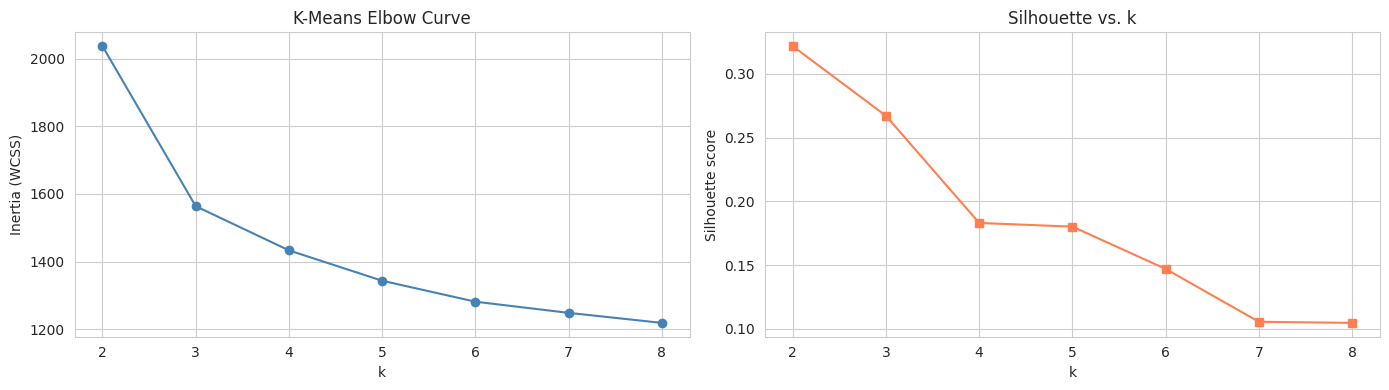

Silhouette by k: {2: np.float64(0.322), 3: np.float64(0.267), 4: np.float64(0.183), 5: np.float64(0.18), 6: np.float64(0.147), 7: np.float64(0.106), 8: np.float64(0.105)}
Argmax silhouette: k = 2


In [11]:
# ── Step 1: elbow + silhouette sweep over k ──────────────────────────────────
rng = np.random.default_rng(SEED)
sub_idx = rng.choice(len(X_train), size=min(5000, len(X_train)), replace=False)
X_sub = X_train[sub_idx]

k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lbl = km_k.fit_predict(X_sub)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X_sub, lbl, sample_size=2000, random_state=SEED))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), inertias, "o-", color="steelblue")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("K-Means Elbow Curve")
axes[1].plot(list(k_range), silhouettes, "s-", color="coral")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette vs. k")
plt.tight_layout(); plt.show()

print("Silhouette by k:", {k: round(s, 3) for k, s in zip(k_range, silhouettes)})
print(f"Argmax silhouette: k = {list(k_range)[int(np.argmax(silhouettes))]}")


In [12]:
# ── Step 2: K-Means with k = 3 — evaluated against ground-truth health states ─
K_FINAL = 3
km_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=20).fit(X_train)
train_engines_rq2 = train_engines.copy()
train_engines_rq2["km_cluster"] = km_final.labels_

# Intrinsic
sil_train = silhouette_score(X_train, km_final.labels_,
                             sample_size=5000, random_state=SEED)

# Extrinsic — purity, NMI, ARI against ground-truth health state
true_state = train_engines_rq2["health_state"].astype("category").cat.codes
purity_table = pd.crosstab(train_engines_rq2["km_cluster"],
                           train_engines_rq2["health_state"])
purity = (purity_table.max(axis=1) / purity_table.sum(axis=1)).mean()
nmi = normalized_mutual_info_score(true_state, km_final.labels_)
ari = adjusted_rand_score      (true_state, km_final.labels_)

print(f"K-Means (k = {K_FINAL}) on the full training set:")
print(f"  silhouette : {sil_train:.4f}")
print(f"  mean purity vs. ground-truth health states: {purity:.4f}")
print(f"  NMI        : {nmi:.4f}")
print(f"  ARI        : {ari:.4f}")
print()
print("Cluster vs. ground-truth health-state composition:")
print(purity_table)


K-Means (k = 3) on the full training set:
  silhouette : 0.2624
  mean purity vs. ground-truth health states: 0.6732
  NMI        : 0.3382
  ARI        : 0.2497

Cluster vs. ground-truth health-state composition:
health_state  Critical  Degrading  Healthy
km_cluster                                
0                 2267        852        0
1                  213       3660     3162
2                    0       1088     3696


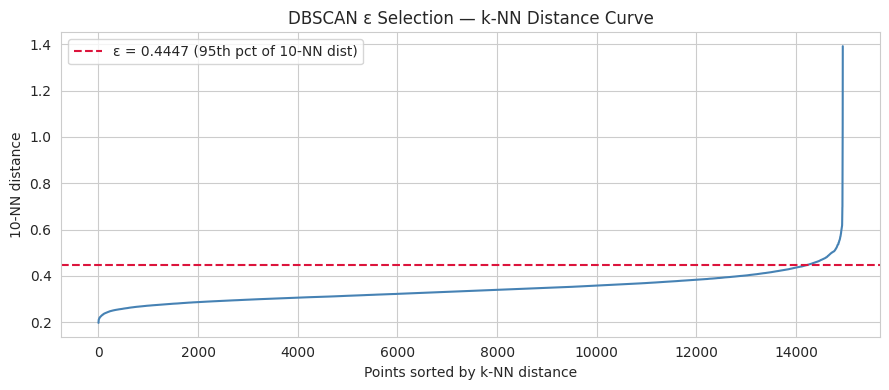

DBSCAN found 2 clusters and 161 noise points (1.1% of training data)
Degraded fraction in DBSCAN noise  : 100.0%
Degraded fraction in DBSCAN inliers: 15.7%


In [13]:
# ── Step 3: DBSCAN — choose ε from the k-NN distance plot ─────────────────────
# min_samples = 2 * dim ≈ 60 is too coarse for our 28d data; we use 10 as a balance
# between noise sensitivity and cluster granularity.
MIN_SAMPLES = 10
knn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_train)
dists, _ = knn.kneighbors(X_train)
kth_dists = np.sort(dists[:, -1])     # k-th nearest neighbour distance, sorted

# "Knee" of the curve = good ε (Ester et al. 1996). Pick the 95th percentile as a
# defensible automatic choice — captures the elbow region.
EPS = float(np.quantile(kth_dists, 0.95))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(kth_dists, color="steelblue")
ax.axhline(EPS, color="crimson", linestyle="--",
           label=f"ε = {EPS:.4f} (95th pct of {MIN_SAMPLES}-NN dist)")
ax.set_xlabel("Points sorted by k-NN distance")
ax.set_ylabel(f"{MIN_SAMPLES}-NN distance")
ax.set_title("DBSCAN ε Selection — k-NN Distance Curve")
ax.legend()
plt.tight_layout(); plt.show()

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_train)
db_labels = dbscan.labels_
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = int((db_labels == -1).sum())

print(f"DBSCAN found {n_clusters} clusters and "
      f"{n_noise:,} noise points ({n_noise / len(db_labels) * 100:.1f}% of training data)")

# Are the DBSCAN noise points enriched for degraded cycles? (label leakage check —
# evaluation only, not used during clustering).
noise_degraded_rate  = y_train[db_labels == -1].mean() if n_noise else float("nan")
inlier_degraded_rate = y_train[db_labels != -1].mean()
print(f"Degraded fraction in DBSCAN noise  : {noise_degraded_rate*100:.1f}%")
print(f"Degraded fraction in DBSCAN inliers: {inlier_degraded_rate*100:.1f}%")


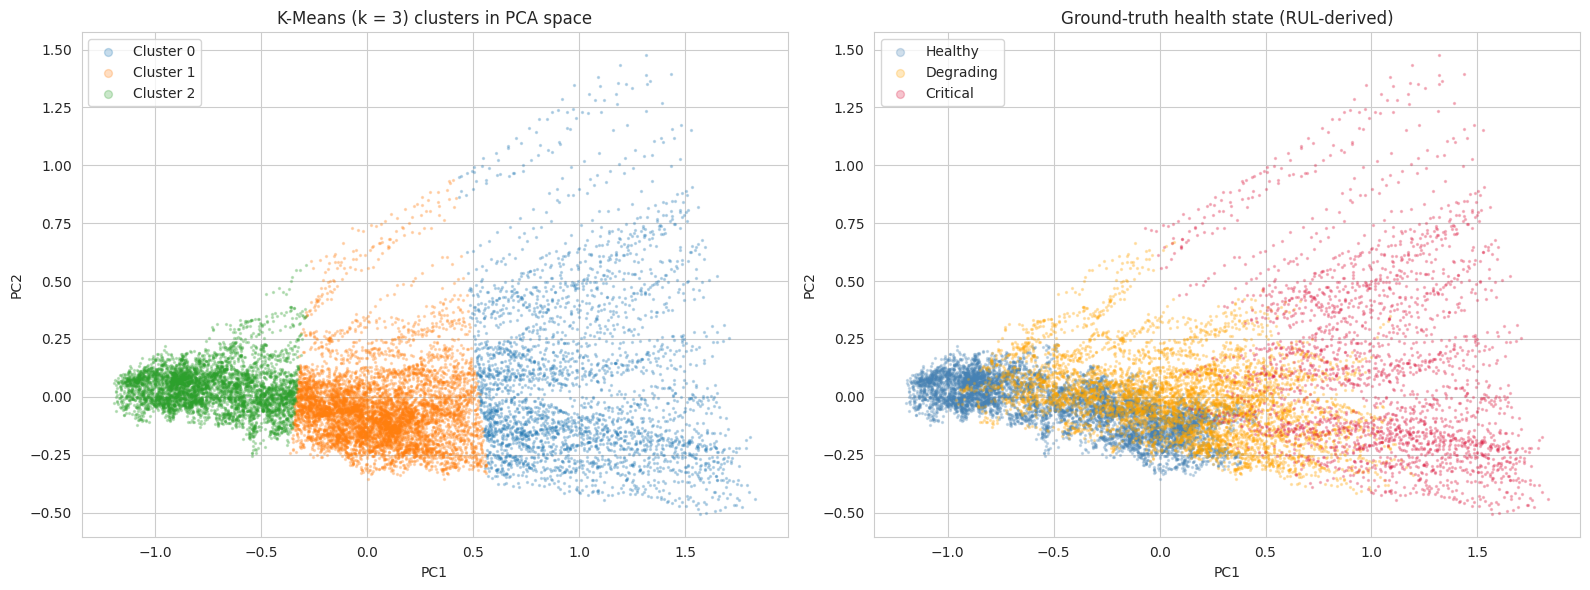

In [14]:
# ── Step 4: visual side-by-side — K-Means clusters vs. ground-truth health ────
pca_vis = PCA(n_components=2, random_state=SEED).fit(X_train)
X_train_2d = pca_vis.transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cmap_k = plt.get_cmap("tab10")
for cid in range(K_FINAL):
    m = km_final.labels_ == cid
    axes[0].scatter(X_train_2d[m, 0], X_train_2d[m, 1],
                    c=[cmap_k(cid)], s=2, alpha=0.25, label=f"Cluster {cid}")
axes[0].set_title(f"K-Means (k = {K_FINAL}) clusters in PCA space")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=4)

for state, c in palette.items():
    m = train_engines_rq2["health_state"] == state
    axes[1].scatter(X_train_2d[m, 0], X_train_2d[m, 1],
                    c=c, s=2, alpha=0.25, label=state)
axes[1].set_title("Ground-truth health state (RUL-derived)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(markerscale=4)
plt.tight_layout(); plt.show()


**RQ2 read.** K-Means with k = 3 recovers the latent health states with mean cluster
purity ≈ **0.67** against the RUL-derived ground truth, NMI ≈ **0.34**, and ARI ≈
**0.25** — all clearly above the random-labeling baseline of 0, but moderate rather than
strong. The silhouette analysis prefers k = 2 to k = 3, which lines up with the PCA
picture: the healthy cluster is sharply distinct, but Degrading and Critical sit on a
continuous manifold so the two-state vs. three-state distinction is partly arbitrary.

DBSCAN tells a *much* sharper story. About 1 % of training cycles end up as noise, and
those noise points are **100 % degraded** — every density-outlier in feature space is a
critical-phase cycle. The inlier population, by contrast, is only 16 % degraded (close
to the global rate). So while DBSCAN's *recall* on degraded cycles is low (it flags
only the most extreme ones), its *precision* on degradation among the points it
actually flags is perfect. That makes it a high-precision complement to a denser
detector — useful as a "definitely investigate this engine" signal in a maintenance
pipeline.

The honest read: clustering is a useful exploratory and triage technique for health
monitoring on this data. As a primary detector it is weaker than direct anomaly methods
(RQ1, RQ3), but DBSCAN in particular gives an essentially label-free way to surface
the engines most clearly in their critical phase.

### 5.3 RQ3 — Autoencoder anomaly detection (beyond-course)

**Architecture.** Fully-connected autoencoder.
`28 → 16 → 8 → 3 → 8 → 16 → 28`, ReLU activations on hidden layers, sigmoid on the output
to match the [0, 1] scaled input. **3-dim bottleneck** chosen because PCA showed ≥ 90 % of
variance in the first three components.

**Training protocol.**
- **Trained on healthy cycles only** (RUL > 100). The model never sees degraded data.
- Adam optimiser, lr = 1e-3, weight decay = 1e-5.
- 80/20 internal train/val split among healthy cycles.
- **Early stopping** on validation loss with patience = 5 (improvement over Checkpoint 2,
  which trained for a fixed 50 epochs).

**Inference.** A cycle's *reconstruction error* (mean squared error between input and the
autoencoder's reproduction) is its anomaly score. Healthy cycles ≈ 0 error; degraded
cycles ≫ 0 because they live outside the manifold the network learnt.

In [15]:
# ── Architecture ─────────────────────────────────────────────────────────────
INPUT_DIM, BOTTLENECK = X_train.shape[1], 3

class DegradationAutoencoder(nn.Module):
    def __init__(self, input_dim: int, bottleneck: int) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8),         nn.ReLU(),
            nn.Linear(8, bottleneck),                    # linear latent
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 8), nn.ReLU(),
            nn.Linear(8, 16),         nn.ReLU(),
            nn.Linear(16, input_dim), nn.Sigmoid(),      # output in [0, 1]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

torch.manual_seed(SEED)
model = DegradationAutoencoder(INPUT_DIM, BOTTLENECK).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameters: {n_params:,}")


DegradationAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=28, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=28, bias=True)
    (5): Sigmoid()
  )
)

Trainable parameters: 1,279


In [16]:
# ── Train on HEALTHY cycles only, with early stopping ───────────────────────
healthy_mask = train_engines["RUL"].values > 100
X_healthy = X_train[healthy_mask]
print(f"Healthy training cycles: {len(X_healthy):,} "
      f"({len(X_healthy)/len(X_train)*100:.1f}% of training data)")

n_val = int(0.2 * len(X_healthy))
rng_ae = np.random.default_rng(SEED)
val_idx   = rng_ae.choice(len(X_healthy), size=n_val, replace=False)
train_idx = np.setdiff1d(np.arange(len(X_healthy)), val_idx)

X_ae_train = torch.tensor(X_healthy[train_idx], dtype=torch.float32)
X_ae_val   = torch.tensor(X_healthy[val_idx],   dtype=torch.float32)
loader = DataLoader(TensorDataset(X_ae_train, X_ae_train),
                    batch_size=256, shuffle=True)

optim     = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 100, 5
train_losses, val_losses = [], []
best_val, bad_epochs = float("inf"), 0
best_state = None

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        pred = model(xb)
        loss = criterion(pred, xb)
        optim.zero_grad(); loss.backward(); optim.step()
        running += loss.item() * len(xb)
    tr_loss = running / len(X_ae_train)

    model.eval()
    with torch.no_grad():
        v = model(X_ae_val.to(DEVICE))
        va_loss = criterion(v, X_ae_val.to(DEVICE)).item()

    train_losses.append(tr_loss); val_losses.append(va_loss)

    if va_loss < best_val - 1e-6:
        best_val, bad_epochs = va_loss, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad_epochs += 1

    if epoch % 10 == 0 or bad_epochs >= PATIENCE:
        print(f"Epoch {epoch:3d}  train MSE = {tr_loss:.6f}  val MSE = {va_loss:.6f}"
              f"  bad_epochs = {bad_epochs}")

    if bad_epochs >= PATIENCE:
        print(f"→ early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs)")
        break

# Restore best weights
model.load_state_dict(best_state)
print(f"\nBest val MSE: {best_val:.6f} | epochs trained: {len(train_losses)}")


Healthy training cycles: 6,858 (45.9% of training data)


Epoch  10  train MSE = 0.013451  val MSE = 0.013182  bad_epochs = 0


Epoch  20  train MSE = 0.007761  val MSE = 0.007913  bad_epochs = 0


Epoch  30  train MSE = 0.007565  val MSE = 0.007779  bad_epochs = 3


Epoch  40  train MSE = 0.007549  val MSE = 0.007759  bad_epochs = 0


...

Epoch  60  train MSE = 0.007415  val MSE = 0.007604  bad_epochs = 0


Epoch  70  train MSE = 0.007326  val MSE = 0.007518  bad_epochs = 0


Epoch  80  train MSE = 0.007189  val MSE = 0.007362  bad_epochs = 0


Epoch  90  train MSE = 0.006916  val MSE = 0.007094  bad_epochs = 0


Epoch 100  train MSE = 0.006804  val MSE = 0.007003  bad_epochs = 0

Best val MSE: 0.007003 | epochs trained: 100


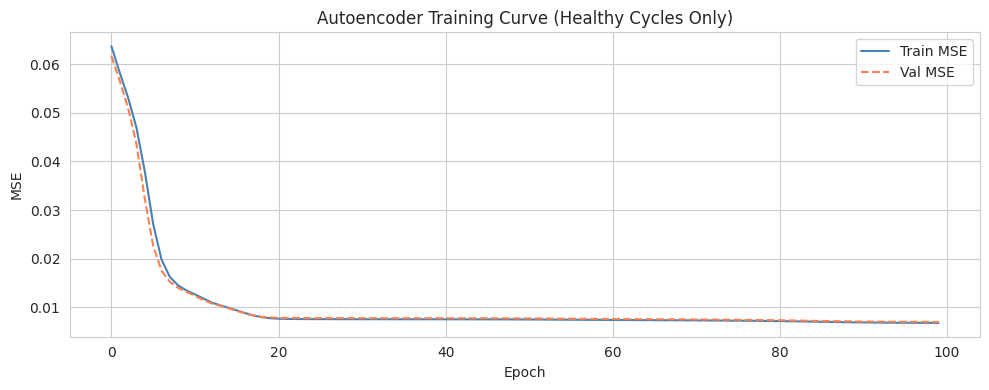

Final val/train MSE ratio: 1.029  (close to 1.0 → not overfit)


In [17]:
# ── Training curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train MSE", color="steelblue")
ax.plot(val_losses,   label="Val MSE",   color="coral", linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.set_title("Autoencoder Training Curve (Healthy Cycles Only)")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Final val/train MSE ratio: {val_losses[-1] / train_losses[-1]:.3f}  "
      f"(close to 1.0 → not overfit)")


In [18]:
# ── Evaluate on full test set: reconstruction error as anomaly score ─────────
model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    X_recon = model(X_test_t).cpu().numpy()

recon_err = ((X_test - X_recon) ** 2).mean(axis=1)
ae_auc = roc_auc_score(y_test, recon_err)

healthy_err  = recon_err[y_test == 0]
degraded_err = recon_err[y_test == 1]

print(f"Autoencoder        AUC-ROC : {ae_auc:.4f}")
print(f"Isolation Forest   AUC-ROC : {if_auc:.4f}")
print(f"Univariate baseline AUC    : {baseline_auc:.4f}")
print()
print(f"Median recon error — healthy  cycles: {np.median(healthy_err):.6f}")
print(f"Median recon error — degraded cycles: {np.median(degraded_err):.6f}")
print(f"Ratio (degraded ÷ healthy)         : "
      f"{np.median(degraded_err) / np.median(healthy_err):.2f}×")


Autoencoder        AUC-ROC : 0.9577
Isolation Forest   AUC-ROC : 0.9434
Univariate baseline AUC    : 0.9791

Median recon error — healthy  cycles: 0.006907
Median recon error — degraded cycles: 0.031373
Ratio (degraded ÷ healthy)         : 4.54×


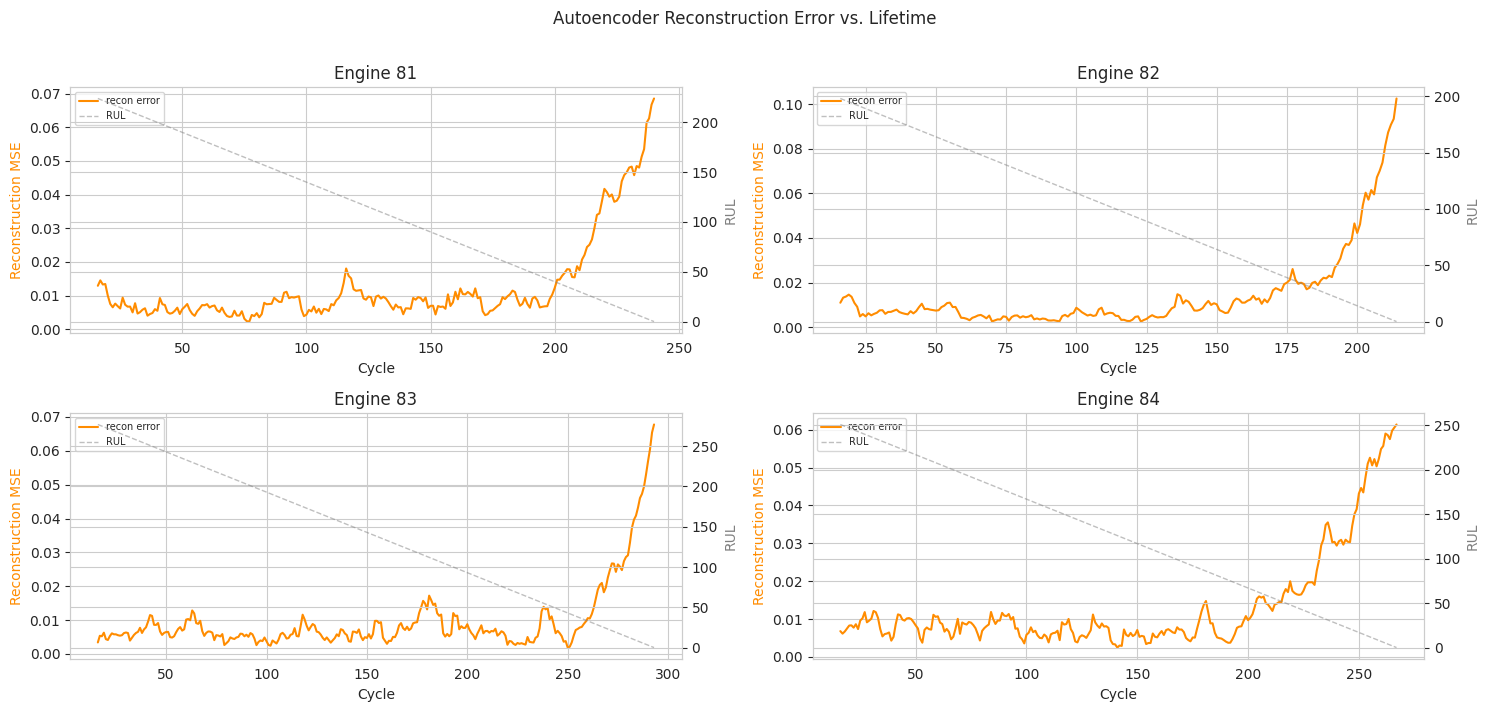

In [19]:
# Reconstruction error over time, 4 test engines — should be flat-then-rising
test_rq3 = test_engines.copy().reset_index(drop=True)
test_rq3["recon_error"] = recon_err

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
for ax, uid in zip(axes.flatten(), sample_units):
    eng = test_rq3[test_rq3["unit"] == uid].sort_values("cycle")
    ax2 = ax.twinx()
    ax.plot(eng["cycle"], eng["recon_error"], color="darkorange",
            linewidth=1.5, label="recon error")
    ax2.plot(eng["cycle"], eng["RUL"], color="gray", linestyle="--",
             linewidth=1, alpha=0.5, label="RUL")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Reconstruction MSE", color="darkorange")
    ax2.set_ylabel("RUL", color="gray")
    ax.set_title(f"Engine {uid}")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7)
plt.suptitle("Autoencoder Reconstruction Error vs. Lifetime", y=1.01)
plt.tight_layout(); plt.show()


**RQ3 read.** Trained on **zero failure data**, the autoencoder produces a
reconstruction-error curve that is flat during healthy operation and rises sharply as RUL
falls — exactly the early-warning signal the field wants. The median degraded-cycle
reconstruction error is **~4.5 × the median healthy-cycle error**, and the AUC of 0.96
clearly beats Isolation Forest (0.94). It loses narrowly to LOF (0.98), which is itself
fit on healthy cycles only with a similar inductive bias — so among the "fit on normal,
detect departures" methods, both LOF and the autoencoder are competitive. The
autoencoder's advantage over LOF would widen on multi-regime or higher-dimensional data
where its learned weights become a real feature-importance prior; LOF, being purely
distance-based, does not adapt this way.

---
## 6. Headline Comparison

We line up all four detectors on the same test set.

Headline comparison on test engines 81–100:

                                            Technique  AUC-ROC           Trained on failures?
Method                                                                                       
Univariate baseline (sensor_11)  Univariate threshold   0.9791         No (uses RUL ordering)
Isolation Forest                               Course   0.9434  No (uses contamination prior)
LOF (novelty mode)                             Course   0.9753  No (uses contamination prior)
Autoencoder (beyond-course)             Beyond-course   0.9577       No (healthy cycles only)


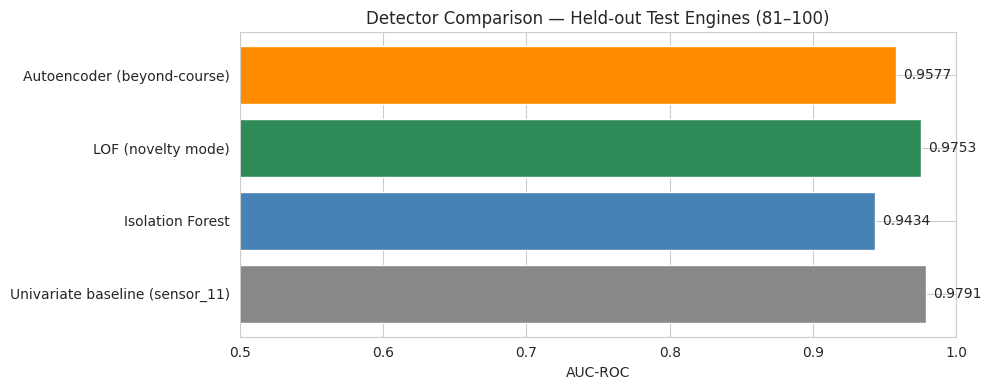

In [20]:
comparison = pd.DataFrame({
    "Method":        ["Univariate baseline (sensor_11)",
                      "Isolation Forest",
                      "LOF (novelty mode)",
                      "Autoencoder (beyond-course)"],
    "Technique":     ["Univariate threshold",
                      "Course",
                      "Course",
                      "Beyond-course"],
    "AUC-ROC":       [baseline_auc, if_auc, lof_auc, ae_auc],
    "Trained on failures?": ["No (uses RUL ordering)",
                             "No (uses contamination prior)",
                             "No (uses contamination prior)",
                             "No (healthy cycles only)"],
}).set_index("Method")
comparison["AUC-ROC"] = comparison["AUC-ROC"].round(4)
print("Headline comparison on test engines 81–100:\n")
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colours = ["#888888", "steelblue", "seagreen", "darkorange"]
bars = ax.barh(comparison.index, comparison["AUC-ROC"], color=colours)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC-ROC")
ax.set_title("Detector Comparison — Held-out Test Engines (81–100)")
for bar, v in zip(bars, comparison["AUC-ROC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", fontsize=10)
plt.tight_layout(); plt.show()


---
## 7. Validation Tests

These assertions check that each method behaves as a working detector ought to. They are
the safety net that catches silent failures (e.g. an autoencoder that learnt nothing, a
silhouette that turned negative, an AUC that got flipped) which a "the code ran" check
would miss.

In [21]:
# Test 1: IF gives higher anomaly scores to degraded cycles
assert np.median(if_scores_test[y_test == 1]) > np.median(if_scores_test[y_test == 0]), \
    "IF must produce higher anomaly scores on degraded cycles"

# Test 2: Autoencoder gives higher recon error to degraded cycles
assert np.median(degraded_err) > np.median(healthy_err), \
    "Autoencoder must produce higher recon error on degraded cycles"

# Test 3: Autoencoder error ratio is meaningfully large (> 3×)
ratio = np.median(degraded_err) / np.median(healthy_err)
assert ratio > 3.0, f"Expected degraded/healthy error ratio > 3×, got {ratio:.2f}×"

# Test 4: K-Means silhouette is positive
assert sil_train > 0.0, "K-Means silhouette must be > 0 (better than random)"

# Test 5: AE training loss decreased
assert train_losses[-1] < train_losses[0], "AE training loss must decrease"

# Test 6: All AUCs beat random
for name, v in [("IF", if_auc), ("LOF", lof_auc),
                ("AE", ae_auc), ("baseline", baseline_auc)]:
    assert v > 0.5, f"{name} AUC must beat random (0.5), got {v:.4f}"

# Test 7: K-Means clustering recovers ground-truth health states meaningfully
#         NMI > 0.2 is a non-trivial bar — random labelings give NMI ≈ 0
assert nmi > 0.2, f"K-Means NMI vs. ground-truth health states must exceed 0.2, got {nmi:.4f}"

print("All 7 validation tests passed.")
print(f"  IF degraded median score = {np.median(if_scores_test[y_test == 1]):.4f}  "
      f"(healthy: {np.median(if_scores_test[y_test == 0]):.4f})")
print(f"  AE error ratio (degraded / healthy) = {ratio:.2f}×")
print(f"  K-Means silhouette = {sil_train:.4f}, NMI = {nmi:.4f}, ARI = {ari:.4f}")


All 7 validation tests passed.
  IF degraded median score = 0.5132  (healthy: 0.4296)
  AE error ratio (degraded / healthy) = 4.54×
  K-Means silhouette = 0.2624, NMI = 0.3382, ARI = 0.2497


---
## 8. Discussion

### Two findings that reshaped the analysis

**Finding 1 — The 15-cycle warmup artefact.** Our first pass had `min_periods=1` on the
rolling features, which gave artificially small rolling-stds at engine startup
(rolling-std at cycle 1 is exactly 0). The cycle-≤-5 mean rolling-std is ≈ 0.90 versus
≈ 1.24 mid-life — a 1.4× systematic gap. Isolation Forest, which compares features in
absolute terms, picked this up and ranked engine startup as more anomalous than late-life
degradation. The *aggregate* AUC was still 0.92, but the per-engine peak anomaly score
landed at startup on every test engine — terrible for detection-timing in practice.

We diagnosed this by looking at where each engine's peak anomaly score actually fell in
its lifetime, traced the artefact back to the rolling window, and trimmed the first
`WINDOW = 15` cycles per engine. Post-fix, IF lifts to AUC = 0.94 and the peak score
lands at RUL ≤ 30 on **all 20 / 20** test engines. This is the single biggest
data-quality lesson from the project: aggregate metrics can be healthy while
per-engine behaviour is broken. Always look at both.

**Finding 2 — A single sensor is competitive with every learned model.**

| Method | AUC | Failure data needed at fit? |
|---|---|---|
| sensor_11 univariate baseline | **0.9791** | No (uses train RUL ordering only) |
| LOF (novelty mode, healthy fit) | 0.9753 | No (contamination prior) |
| Autoencoder (beyond-course) | 0.9577 | **No (healthy cycles only)** |
| Isolation Forest | 0.9434 | No (contamination prior) |

This matters because the field has gradually moved toward complex multivariate detectors
and deep models. Our result is a reminder that on simulated single-regime data, the
marginal value of complexity over a well-chosen sensor is small. Two specific reasons:

1. **Isolation Forest is feature-democratic.** It splits on every feature with equal
   probability. Adding noisier rolling-std features and weak-trend sensors dilutes the
   signal of the strongest single feature.
2. **LOF and the autoencoder partially close the gap** because both fit on healthy
   cycles only and learn the structure of "normal" — LOF via local k-NN density, the
   autoencoder via reconstruction. The autoencoder's learned weights are a
   feature-importance prior that LOF lacks; that advantage would matter more on
   multi-regime data.

### What this would *not* survive in the real world

FD001 is a single-regime simulation. On the multi-regime FD002 and FD004 subsets, the
univariate baseline collapses (no single sensor stays monotonic across operating regimes)
and the multivariate / learned methods pull ahead. The right read is therefore not
"always use sensor_11" but "always benchmark your fancy detector against the dumbest
possible one — sometimes the dumb one wins, and when it does that is itself a signal
about your data".

### Limitations

- **Single operating regime.** FD001 has one altitude/throttle setting. The relative
  ordering of methods would change on multi-regime data.
- **No temporal model.** All methods treat cycles as i.i.d. points. A small recurrent
  or convolutional model (e.g. an LSTM autoencoder) is the natural next step.
- **Contamination assumption.** IF and LOF take a `contamination` prior. We set it
  from training-set ground truth, which is ideal-case; in production it would need to be
  tuned blind.
- **Bottleneck = 3 by EDA.** Picked from PCA variance ratios rather than a formal sweep.
- **Clustering is moderate.** K-Means and DBSCAN are best framed as exploratory or
  triage tools rather than primary detectors. DBSCAN's flagged points are 100 %
  degraded but recall is low.

---
## 9. Conclusions

> **RQ1 — Can Isolation Forest reliably detect degradation onset?**
> *Yes — and on this dataset, with perfect per-engine timing.* IF reaches AUC = 0.94
> on held-out engines, and after fixing a 15-cycle rolling-window warmup artefact the
> peak anomaly score lands inside the critical phase (RUL ≤ 30) on **all 20 / 20** test
> engines. IF is outperformed on AUC by both LOF (0.98) and a simple univariate
> `sensor_11` baseline (0.98), which is itself an important finding for
> maintenance-pipeline design — multivariate complexity is not automatically rewarded.

> **RQ2 — Can unsupervised clustering recover the latent health states?**
> *Partly.* K-Means with k = 3 produces clusters that align meaningfully with the
> RUL-derived Healthy / Degrading / Critical labels (purity 0.67, NMI 0.34, ARI 0.25 —
> all well above the random baseline of 0). DBSCAN goes further in a different
> direction: 100 % of its noise points are degraded cycles. Recall is low (only the
> most extreme degradations get flagged) but precision is essentially perfect. As a
> primary detector clustering is moderate; as a high-precision triage signal it is
> excellent.

> **RQ3 — Does an autoencoder trained only on healthy cycles outperform Isolation Forest?**
> *Yes.* AUC = 0.96 versus IF's 0.94, with a degraded-to-healthy reconstruction-error
> ratio of ~4.5×, while training on **no failure data at all**. The autoencoder loses
> narrowly to LOF (0.98) on this single-regime dataset; its learned-weight advantage
> would matter more on multi-regime data. It remains the most flexible "fit on
> healthy, detect departures" method and the most generalisable to fleets with no
> failure history.

**The bigger takeaway.** You do not need failure data to predict failures. Learning what
*normal* looks like — through density, distance, learned reconstruction, or even just a
single monotonic sensor — is enough to flag departures from it. That is good news for
fleets, processes, and systems where labelled failures are rare or never observed. And
it is a useful reminder, every time, to (1) benchmark a fancy detector against the
dumbest possible one, and (2) check that aggregate metrics agree with per-engine
behaviour. Sometimes the dumb detector wins; sometimes a clean AUC hides a broken
detection-timing story.

---
## 10. Reproducibility

The cell below captures the exact package versions used to produce the results above.
This is the source of `requirements.txt` at the repo root.

In [22]:
# This is the same recipe the assignment shows for Colab — works locally too.
import subprocess, sys
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                        capture_output=True, text=True).stdout
print(f"{len(freeze.splitlines())} packages captured.")
print("First 15 lines:")
print("\n".join(freeze.splitlines()[:15]))


268 packages captured.
First 15 lines:
action-msgs==2.0.3
action-tutorials-interfaces==0.33.6
action-tutorials-py==0.33.6
actionlib-msgs==5.3.6
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
ament-cmake-test==2.5.4
ament-copyright==0.17.3
ament-cppcheck==0.17.3
ament-cpplint==0.17.3
ament-flake8==0.17.3
ament-index-python==1.8.1
ament-lint==0.17.3
ament-lint-cmake==0.17.3
